# Model-free control

- On-Policy Monte-Carlo Control
- On-Policy Temporal-Diﬀerence Learning
- Oﬀ-Policy Learning

**Model-free prediction**

-> Estimate the value function of an unknown MDP

**Model-free control**

-> Optimise value function of an unknown MDP

For most problems:

- MDP model is unknown, but experience can be sampled
- MDP model is known, but too big to use, except by samples


**On-policy** learning

- "learn on the job"
- learn about policy $\pi$ from experience sampled from $\pi$

**Off-policy** learning

- "Look over someone's shoulder"
- Learn about policy $\pi$ from experience sampled from $\mu$


## Introduction

### Generalized policy iteration (refresher)

<img src="./imgs/image-92.png" width="600px"/>

### Generalized policy iteration with monte-carlo evaluation

<img src="./imgs/image-93.png" width="600px"/>



### Generalized policy iteration (refresher)

<img src="./imgs/image-92.png" width="600px"/>

Model-Free Policy Iteration Using Action-Value Function

- Greedy policy improvement over $V(s)$ requires model of MDP

$$\pi'(s) = \argmax_{a \in \mathcal{A}} \mathcal{R}_s^a + \mathcal{P}_{ss'}^a V(s')$$

to evaluate action a from state s, need immediate reward and transition probability to next state, so a model that we don't have

- Greedy policy improvement over $Q(s, a)$ is model-free

$$\pi'(s) = \argmax_{a \in \mathcal{A}} Q(s, a)$$

Q(s,a) encode "how good is action a from state s" -> juste juste need argmax of Q, no model needed. 

Q-functions are more practical because you can improve policy without knowing env dynamics.

-> To improve a policy greedily, pick the action that looks best from the current state.


### Generalised Policy Iteration with Action-Value Function


<img src="./imgs/image-94.png" width="600px"/>

### $\epsilon$-Greedy exploration

- Simplest idea for ensuring continual exploration
- All m actions are tried with non-zero probability
- With probability 1−ϵ choose the greedy action
- With probability ϵ choose an action at random

$$
\pi(a|s) = \begin{cases} \epsilon/m + 1 - \epsilon & \text{if } a^* = \underset{a \in \mathcal{A}}{\argmax} \ Q(s, a) \\ \epsilon/m & \text{otherwise} \end{cases}
$$

When policy is optimal, we always use greedy action. The goal is to find the greedy action.  Exploration is only to learn



### $\epsilon$-Greedy policy improvement

**Theorem**

For any $\epsilon$-greedy policy $\pi$, the $\epsilon$-greedy policy $\pi'$ with respect to $q_\pi$ is an improvement, $v_{\pi'}(s) \geq v_\pi(s)$*

-> Greedifying an ε-greedy policy always improves it (or keeps it the same).

- You have policy π (ε-greedy), and you build π' by acting greedier with respect to π's Q-values
- The proof shows that the value of following π' from any state is at least as good as following π
-----
Proof:

$$
\begin{aligned}
q_\pi(s, \pi'(s)) &= \sum_{a \in \mathcal{A}} \pi'(a|s) q_\pi(s, a) \\
&= \epsilon/m \sum_{a \in \mathcal{A}} q_\pi(s, a) + (1 - \epsilon) \max_{a \in \mathcal{A}} q_\pi(s, a) \\
&\geq \epsilon/m \sum_{a \in \mathcal{A}} q_\pi(s, a) + (1 - \epsilon) \sum_{a \in \mathcal{A}} \frac{\pi(a|s) - \epsilon/m}{1 - \epsilon} q_\pi(s, a) \\
&= \sum_{a \in \mathcal{A}} \pi(a|s) q_\pi(s, a) = v_\pi(s)
\end{aligned}
$$

Therefore from policy improvement theorem, $v_{\pi'}(s) \geq v_\pi(s)$

line 2/3: max is replaced by weighted sum using the greedy part of $\pi$ so

$$\max_{a} q_\pi(s,a) \geq \sum_a \frac{\pi(a|s) - \epsilon/m}{1-\epsilon} q_\pi(s,a)$$

the best action's value ≥ the weighted average value under π's greedy part. Obvious, since max ≥ average.


## Monte-carlo

### Monte-carlo policy iteration

- Policy evaluation:  Monte-Carlo policy evaluation, $Q=q_\pi$ 
- Policy improvement: ϵ-greedy policy improvement

### Monte-carlo control

**On every episode**

So we don't wait for many episodes to evaluate and update policy

- Policy evaluation: Monte-Carlo policy evaluation, $Q \approx q_\pi$, 
- Policy improvement: ϵ-greedy policy improvement


### GLIE

**Definition**

*Greedy in the Limit with Infinite Exploration* (GLIE):  is a condition that guarantees Monte Carlo control converges to the optimal policy. It requires two things:

- All state-action pairs are explored infinitely many times (infinite exploration),

$$\lim_{k \to \infty} N_k(s, a) = \infty$$

- The policy converges on a greedy policy (eventual greediness),

$$\lim_{k \to \infty} \pi_k(a|s) = \mathbf{1}(a = \underset{a' \in \mathcal{A}}{\argmax} \ Q_k(s, a'))$$

The policy must become fully greedy in the limit — so it actually exploits what it learned.

**The tension**: exploration vs exploitation

- You need enough exploration to learn accurate Q-values
- But you need to stop exploring eventually to act optimally

For example, $\epsilon$-greedy is GLIE if $\epsilon$ reduces to zero at $\epsilon_k = \frac{1}{k}$, (We apply a schedule to $\epsilon$): 

- $\epsilon_k  \to 0$, so policy becomes greedy
- $\epsilon_k  \to 0$ decreases slowly enough that all pairs are visited infinitely often




#### GLIE Monte-carlo

- Sample $k$th episode using $\pi$: $\{S_1, A_1, R_2, ..., S_T\} \sim \pi$
- For each state $S_t$ and action $A_t$ in the episode,

$$N(S_t, A_t) \leftarrow N(S_t, A_t) + 1$$

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)}\left(G_t - Q(S_t, A_t)\right)$$

- Improve policy based on new action-value function

$$\epsilon \leftarrow 1/k$$

$$\pi \leftarrow \epsilon\text{-greedy}(Q)$$

**Theorem**

*GLIE Monte-Carlo control converges to the optimal action-value function, $Q(s,a) \to q_*(s,a)$*

**Explanation**

This is GLIE Monte-Carlo control — the full algorithm:

1. **Run episode** using current $\epsilon$-greedy policy, collect trajectory
2. **Update Q** for each visited $(S_t, A_t)$: incremental mean update — $Q$ moves toward the return $G_t$ (actual cumulative reward from that point)
3. **Shrink $\epsilon$** as $1/k$ — exploration decreases each episode
4. **Greedify** — update policy to be $\epsilon$-greedy w.r.t. new $Q$

Because $\epsilon = 1/k$ satisfies GLIE conditions, the theorem guarantees $Q \to q_*$ — you learn the optimal action-values.

In [4]:
import numpy as np
import pandas as pd
import random


# ── Card helpers ─────────────────────────────────────────────────────
def get_card():
    card = random.randint(1, 13)
    return min(card, 10)


def get_score(hand):
    """Returns (sum, has_usable_ace)"""
    score = sum(hand)
    usable_ace = False
    if 1 in hand and score + 10 <= 21:
        score += 10
        usable_ace = True
    return score, usable_ace


# ── Environment ──────────────────────────────────────────────────────
class BlackjackEnv:
    """Blackjack environment. Returns states as (player_sum, dealer_card, usable_ace)."""

    def reset(self):
        """Deal a new hand and return the initial state."""
        self.player_hand = [get_card(), get_card()]
        self.dealer_up_card = get_card()

        # Auto-twist until decision zone [12..21]
        p_sum, usable_ace = get_score(self.player_hand)
        while p_sum < 12:
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

        self.done = False
        return (p_sum, self.dealer_up_card, usable_ace)

    def step(self, action):
        """Take an action ('twist' or 'stick'). Returns (next_state, reward, done)."""
        if action == "twist":
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            while p_sum < 12:
                self.player_hand.append(get_card())
                p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            next_state = (p_sum, self.dealer_up_card, usable_ace)
            return next_state, 0.0, False

        else:  # stick -> dealer plays, episode ends
            dealer_hand = [self.dealer_up_card, get_card()]
            d_sum, _ = get_score(dealer_hand)
            while d_sum < 17:
                dealer_hand.append(get_card())
                d_sum, _ = get_score(dealer_hand)

            p_final, _ = get_score(self.player_hand)
            if d_sum > 21 or p_final > d_sum:
                reward = 1.0
            elif p_final == d_sum:
                reward = 0.0
            else:
                reward = -1.0

            self.done = True
            return None, reward, True

### GLIE Monte-Carlo Control — Blackjack

Apply GLIE MC control to the Blackjack environment:

- **State**: `(player_sum, dealer_card, usable_ace)` — player sum ∈ [12, 21], dealer showing ∈ [1, 10], usable ace ∈ {True, False}
- **Actions**: `twist` (hit) or `stick` (stand)
- **Q-table**: shape `(10, 10, 2, 2)` — indexed by `(player_sum - 12, dealer_card - 1, usable_ace, action)`
- **ε schedule**: $\epsilon_k = 1/k$ (GLIE condition)

The algorithm learns $Q(s, a) \to q_*(s, a)$ and derives the optimal policy $\pi^*$.

In [5]:
import matplotlib.pyplot as plt

ACTIONS = ["twist", "stick"]

# ── Helpers ──────────────────────────────────────────────────────────
def state_to_idx(state):
    """(player_sum, dealer_card, usable_ace) → numpy index tuple."""
    p_sum, d_card, u_ace = state
    return (p_sum - 12, d_card - 1, int(u_ace))


def epsilon_greedy_action(Q, state, epsilon):
    """Pick action via ε-greedy w.r.t. Q."""
    idx = state_to_idx(state)
    if np.random.random() < epsilon:
        return np.random.randint(len(ACTIONS))
    return int(np.argmax(Q[idx]))


# ── GLIE Monte-Carlo Control ────────────────────────────────────────
def glie_mc_control(n_episodes=500_000, gamma=1.0):
    # Q(player_sum, dealer_card, usable_ace, action)
    Q = np.zeros((10, 10, 2, len(ACTIONS)))
    N = np.zeros_like(Q)

    env = BlackjackEnv()

    for k in range(1, n_episodes + 1):
        epsilon = 1.0 / k

        # ── Generate episode using ε-greedy(Q) ──
        state = env.reset()
        episode = []  # list of (state, action, reward)

        done = False
        while not done:
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done = env.step(ACTIONS[action])
            episode.append((state, action, reward))
            if not done:
                state = next_state

        # ── Update Q for each first-visit (s, a) ──
        G = 0.0
        visited = set()
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            sa = (*state_to_idx(state), action)
            if sa not in visited:
                visited.add(sa)
                N[sa] += 1
                Q[sa] += (1.0 / N[sa]) * (G - Q[sa])

    return Q, N


Q, N = glie_mc_control(n_episodes=500_000, gamma=1.0)

# ── Derive greedy policy from Q ──────────────────────────────────────
policy = np.argmax(Q, axis=-1)  # shape (10, 10, 2): 0 = twist, 1 = stick

print("Training complete.")
print(f"States visited at least once: {int((N.sum(axis=-1) > 0).sum())} / {10*10*2}")


Training complete.
States visited at least once: 200 / 200


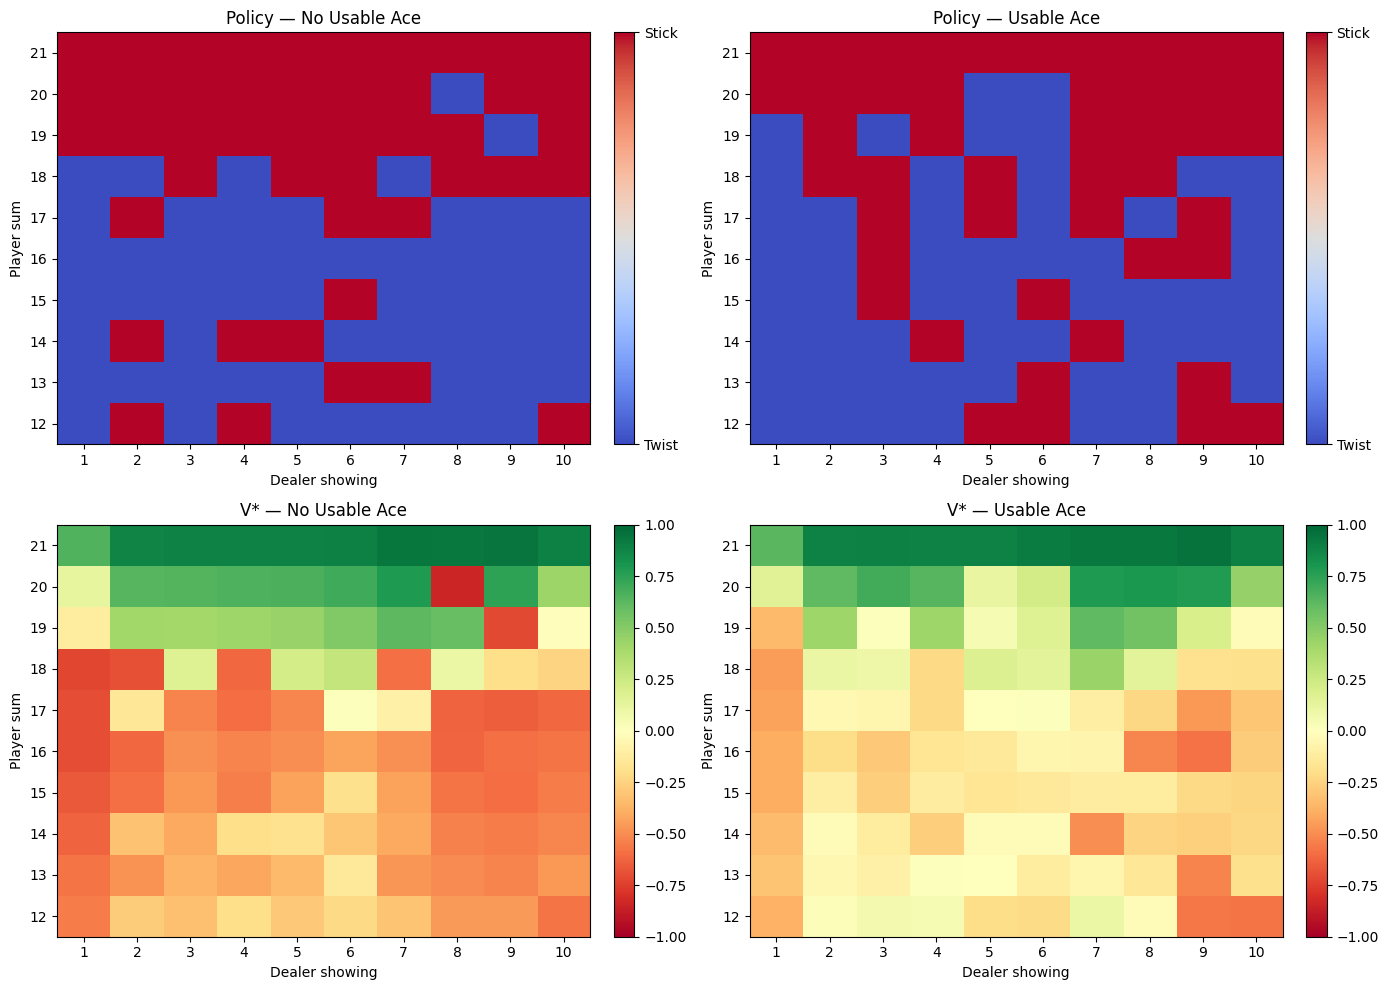

In [6]:
# ── Visualise learned policy & value function ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "Policy — No Usable Ace",
    "Policy — Usable Ace",
    "V* — No Usable Ace",
    "V* — Usable Ace",
]

for col, u_ace in enumerate([0, 1]):
    # ── Policy heatmap ──
    ax = axes[0, col]
    im = ax.imshow(
        policy[:, :, u_ace],
        cmap="coolwarm",
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax.set_title(titles[col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

    # ── Value function heatmap: V*(s) = max_a Q(s, a) ──
    V_star = np.max(Q[:, :, u_ace, :], axis=-1)
    ax = axes[1, col]
    im = ax.imshow(
        V_star,
        cmap="RdYlGn",
        origin="lower",
        aspect="auto",
        vmin=-1,
        vmax=1,
    )
    ax.set_title(titles[2 + col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## MC vs TD control

- Temporal-diﬀerence (TD) learning has several advantages
over Monte-Carlo (MC)
    - Lower variance
    - Online
    - Incomplete sequences
- Natural idea: use TD instead of MC in our control loop
    - Apply TD to Q(S,A)
    - Use ϵ-greedy policy improvement
    - Update every time-step

    

## TD control - SARSA

<img src="./imgs/image-95.png" width="500px"/>

### On-policy control with Sarsa

**Every time-step:**
- Policy evaluation Sarsa, $Q \approx q_{\pi}$ 
- Policy improvement ϵ-greedy policy improvement

### Sarsa Algorithm for On-Policy Control

Initialize $Q(s, a)$, $\forall s \in \mathcal{S}$, $a \in \mathcal{A}(s)$, arbitrarily, and $Q(\textit{terminal-state}, \cdot) = 0$


- Repeat (for each episode):

    - Initialize $S$
    - Choose $A$ from $S$ using policy derived from $Q$ (e.g., $\varepsilon$-greedy)
    - Repeat (for each step of episode):

        - Take action $A$, observe $R$, $S'$

        - Choose $A'$ from $S'$ using policy derived from $Q$ (e.g., $\varepsilon$-greedy)

        - $Q(S, A) \leftarrow Q(S, A) + \alpha\left[R + \gamma Q(S', A') - Q(S, A)\right]$

        - $S \leftarrow S'$; $A \leftarrow A'$;

    - until $S$ is terminal



SARSA learns the value of state-action pairs $Q(s,a)$ by actually experiencing transitions.

**The update rule:**
$$Q(S, A) \leftarrow Q(S, A) + \alpha\left[R + \gamma Q(S', A') - Q(S, A)\right]$$

- $Q(S,A)$ — current estimate of "how good is action A in state S"
- $R + \gamma Q(S', A')$ — what you actually got (reward) + discounted value of where you ended up
- The difference in brackets is the **TD error** — how wrong your current estimate was
- $\alpha$ — learning rate, controls how fast you update

**Key characteristic:** It's **on-policy** — the $A'$ you use for the update is the action you *actually take* next (from the same $\varepsilon$-greedy policy), not the theoretical best action. This makes it more conservative than Q-learning, which would use $\max_{a'} Q(S', a')$ instead.

### Theorem


SARSA converges to the true optimal $q_*(s,a)$ if two conditions hold:

**1. GLIE policy** — the policy must:
- explore everywhere infinitely often (never stop trying actions)
- eventually become greedy (exploitation wins in the limit)

e.g. $\varepsilon$-greedy with $\varepsilon_t \rightarrow 0$ slowly enough

**2. Robbins-Monro step sizes** — $\alpha_t$ must:
- $\sum \alpha_t = \infty$ — steps are large enough to overcome any initial conditions / noise
- $\sum \alpha_t^2 < \infty$ — steps shrink enough that updates eventually stabilize

e.g. $\alpha_t = 1/t$ satisfies both: $\sum 1/t = \infty$ and $\sum 1/t^2 < \infty$

In practice these conditions are rarely enforced strictly — constant $\alpha$ and fixed $\varepsilon$ work fine empirically.

----

Robbins-Monro (1951) is a general condition for stochastic approximation to converge.

The idea: you're trying to solve $f(\theta) = 0$ using noisy estimates of $f$.
You update iteratively: $\theta_{t+1} = \theta_t - \alpha_t \hat{f}(\theta_t)$

It converges if step sizes satisfy:
$$\sum \alpha_t = \infty \qquad \sum \alpha_t^2 < \infty$$

**Intuition:**
- First condition: steps must be large enough in total to reach the solution from anywhere
- Second condition: steps must shrink so the noise averages out and you don't keep bouncing around

**In SARSA/TD context:** the TD update is exactly this kind of noisy fixed-point iteration,
so the same conditions guarantee convergence of $Q(s,a) \rightarrow q_*(s,a)$.

### Sarsa in windy gridworld

<img src="./imgs/image-96.png" width="500px"/><div/>


<img src="./imgs/image-97.png" width="500px"/>

In [7]:

# ── SARSA Control — Blackjack ────────────────────────────────────────
def sarsa_control(n_episodes=500_000, alpha=0.01, gamma=1.0, epsilon_start=1.0):
    """
    On-policy SARSA with ε-greedy exploration on Blackjack.
    ε decays as 1/k (GLIE schedule).
    """
    Q = np.zeros((10, 10, 2, len(ACTIONS)))
    env = BlackjackEnv()

    episode_rewards = []

    for k in range(1, n_episodes + 1):
        epsilon = max(epsilon_start / k, 0.01)

        state = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon)
        total_reward = 0.0

        done = False
        while not done:
            next_state, reward, done = env.step(ACTIONS[action])
            total_reward += reward

            if done:
                # Terminal: Q(S', A') = 0, so target = R
                sa = (*state_to_idx(state), action)
                Q[sa] += alpha * (reward - Q[sa])
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                sa = (*state_to_idx(state), action)
                sa_next = (*state_to_idx(next_state), next_action)
                Q[sa] += alpha * (reward + gamma * Q[sa_next] - Q[sa])
                state = next_state
                action = next_action

        episode_rewards.append(total_reward)

    return Q, episode_rewards


SARSA training complete.
States visited at least once: 200 / 200


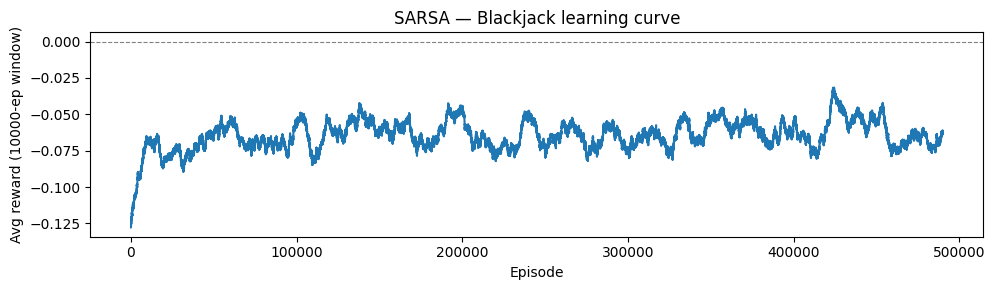

In [8]:

Q_sarsa, rewards_sarsa = sarsa_control(n_episodes=500_000, alpha=0.01, gamma=1.0)

policy_sarsa = np.argmax(Q_sarsa, axis=-1)
print("SARSA training complete.")
print(f"States visited at least once: {int((Q_sarsa.any(axis=-1)).sum())} / {10*10*2}")

# Running average reward
window = 10_000
avg_rewards = np.convolve(rewards_sarsa, np.ones(window) / window, mode="valid")
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(avg_rewards)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Avg reward ({window}-ep window)")
ax.set_title("SARSA — Blackjack learning curve")
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


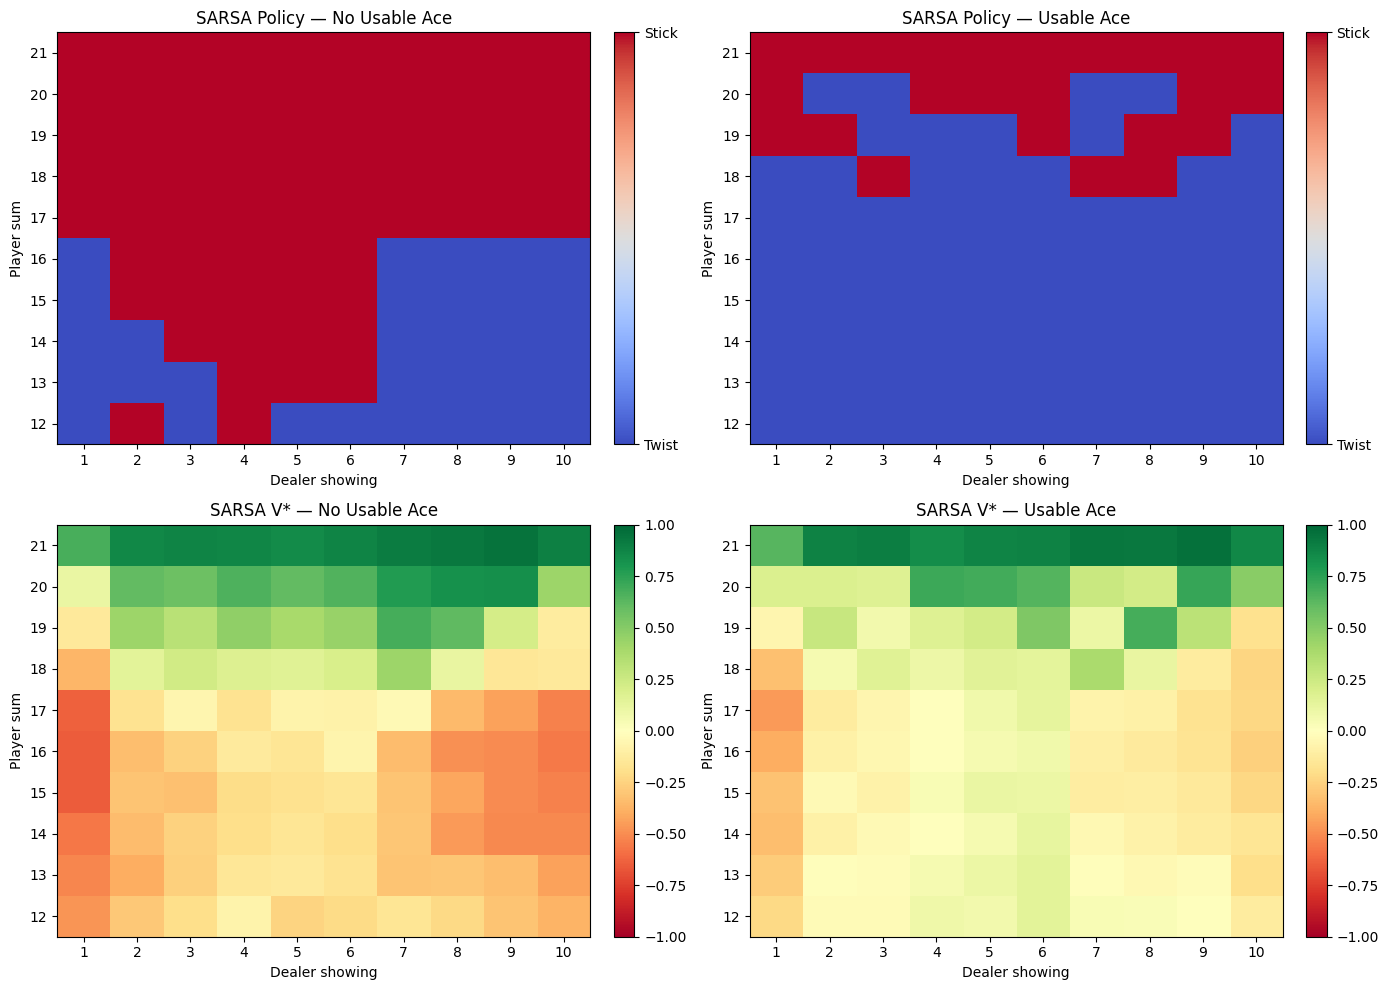

In [9]:

# ── Visualise SARSA policy & value function ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "SARSA Policy — No Usable Ace",
    "SARSA Policy — Usable Ace",
    "SARSA V* — No Usable Ace",
    "SARSA V* — Usable Ace",
]

for col, u_ace in enumerate([0, 1]):
    # ── Policy heatmap ──
    ax = axes[0, col]
    im = ax.imshow(
        policy_sarsa[:, :, u_ace],
        cmap="coolwarm",
        origin="lower",
        aspect="auto",
        vmin=0, vmax=1,
    )
    ax.set_title(titles[col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

    # ── Value function heatmap ──
    V_sarsa = np.max(Q_sarsa[:, :, u_ace, :], axis=-1)
    ax = axes[1, col]
    im = ax.imshow(
        V_sarsa,
        cmap="RdYlGn",
        origin="lower",
        aspect="auto",
        vmin=-1, vmax=1,
    )
    ax.set_title(titles[2 + col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


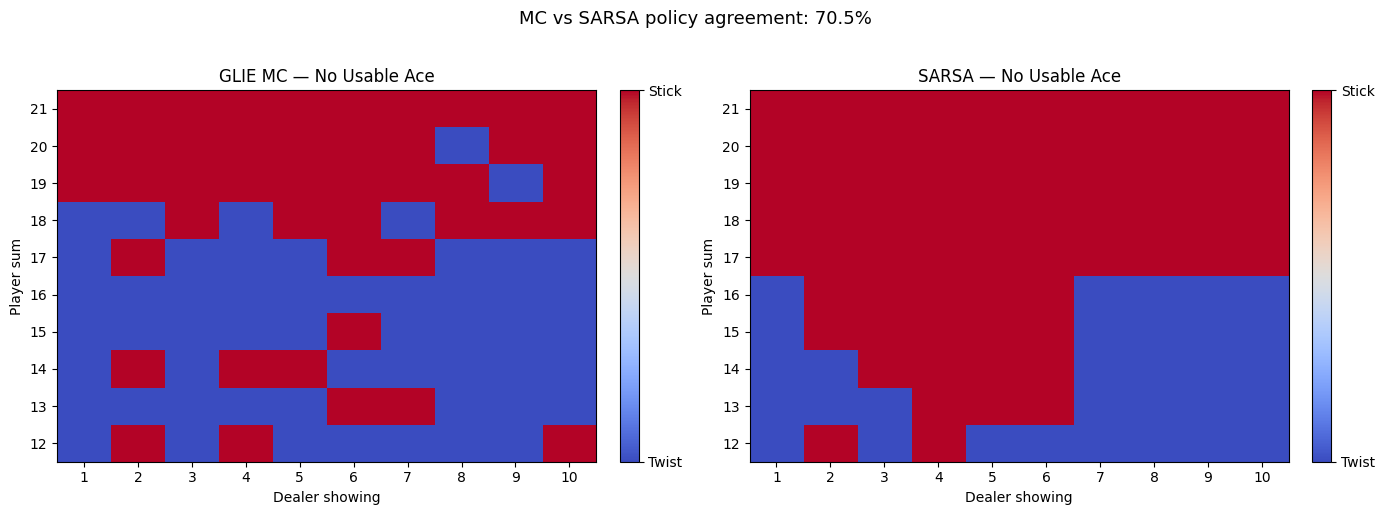

In [10]:

# ── Compare MC vs SARSA policies ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, (label, pol) in enumerate([("GLIE MC", policy), ("SARSA", policy_sarsa)]):
    diff = pol[:, :, 0]  # no usable ace
    ax = axes[col]
    im = ax.imshow(diff, cmap="coolwarm", origin="lower", aspect="auto", vmin=0, vmax=1)
    ax.set_title(f"{label} — No Usable Ace")
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

agree = (policy == policy_sarsa).mean() * 100
fig.suptitle(f"MC vs SARSA policy agreement: {agree:.1f}%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### n-Step Sarsa

Consider the following $n$-step returns for $n = 1, 2, \infty$:

$$n = 1 \quad \text{(Sarsa)} \qquad q_t^{(1)} = R_{t+1} + \gamma Q(S_{t+1})$$
$$n = 2 \qquad\qquad\qquad\quad q_t^{(2)} = R_{t+1} + \gamma R_{t+2} + \gamma^2 Q(S_{t+2})$$
$$\vdots \qquad\qquad\qquad\qquad\qquad \vdots$$
$$n = \infty \quad \text{(MC)} \qquad q_t^{(\infty)} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-1} R_T$$

Define the $n$-step Q-return:

$$q_t^{(n)} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n} + \gamma^n Q(S_{t+n})$$

$n$-step Sarsa updates $Q(s, a)$ towards the $n$-step Q-return:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left( q_t^{(n)} - Q(S_t, A_t) \right)$$

----

Standard SARSA bootstraps after 1 step. But you can look further ahead before bootstrapping.

**The spectrum:**

| n | name | target |
|---|------|--------|
| 1 | SARSA | immediate reward + estimated value of next state |
| 2 | 2-step | 2 real rewards + estimated value of state after that |
| $\infty$ | Monte Carlo | all real rewards until episode ends, no bootstrap |

**General formula:**
$$q_t^{(n)} = \underbrace{R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n}}_{\text{n real rewards}} + \underbrace{\gamma^n Q(S_{t+n})}_{\text{then bootstrap}}$$

**Intuition:**
- Small $n$: low variance, but biased (relies on potentially wrong $Q$ estimates)
- Large $n$: less bias (more real data), but higher variance
- $n = \infty$ (MC): unbiased but high variance, and needs complete episodes

The update is still just: move $Q(S_t, A_t)$ toward the $n$-step target.

## Sarsa($\lambda$)

<img src="./imgs/image-98.png" width="400px"/><div/>


Instead of picking a single $n$, Sarsa($\lambda$) blends **all** $n$-step returns at once.

- The $q^\lambda$ return combines all $n$-step Q-returns $q_t^{(n)}$ 


- using weight $(1-\lambda)\lambda^{n-1}$:

    $$q_t^\lambda = (1-\lambda) \sum_{n=1}^{\infty} \lambda^{n-1} q_t^{(n)}$$

    **Weights:** longer horizons get exponentially less weight

    $$n=1: \quad (1-\lambda)$$
    $$n=2: \quad (1-\lambda)\lambda$$
    $$n=3: \quad (1-\lambda)\lambda^2$$
    $$\vdots$$

    Weights $(1-\lambda)\lambda^{n-1}$ decay geometrically with $n$, and sum to 1.  

    **$\lambda$ controls the blend:**
    - $\lambda = 0$ → pure SARSA (only 1-step)
    - $\lambda = 1$ → pure Monte Carlo (all weight on full return)
    - $0 < \lambda < 1$ → smooth interpolation, nearby steps matter most


- **Forward-view Sarsa($\lambda$):**

    $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left( q_t^\lambda - Q(S_t, A_t) \right)$$


**Intuition:** rather than committing to a fixed lookahead, use all of them — but trust short-term real rewards more than distant ones.

The update is identical in form to $n$-step SARSA, just with $q_t^\lambda$ as the target.

### Backward-view Sarsa($\lambda$) with Eligibility Traces

Just like $TD(\lambda)$, we use eligibility traces in an online algorithm

One eligibility trace per state-action pair:

$$E_0(s, a) = 0$$
$$E_t(s, a) = \gamma\lambda E_{t-1}(s, a) + \mathbf{1}(S_t = s, A_t = a)$$

At each step, compute TD-error and update **all** $(s,a)$ pairs:

$$\delta_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)$$
$$Q(s, a) \leftarrow Q(s, a) + \alpha \delta_t E_t(s, a)$$

---

**Intuition:**

$E_t(s,a)$ tracks how recently and frequently $(s,a)$ was visited:
- Spikes up by 1 each time $(s,a)$ is visited
- Decays by $\gamma\lambda$ every step otherwise

When a TD-error $\delta_t$ occurs, every $(s,a)$ gets updated —
but those visited recently/often (high $E$) get updated more.

**Effect:** credit for a reward is propagated back to all recently visited
state-action pairs, not just the current one.

**$\lambda$ controls memory:**
- $\lambda = 0$ → traces vanish immediately → pure 1-step SARSA
- $\lambda = 1$ → traces decay only by $\gamma$ → approaches MC

### Sarsa(λ) Algorithm

- Initialize $Q(s, a)$ arbitrarily, for all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$

- Repeat (for each episode):
  - $E(s, a) = 0$, for all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$
  - Initialize $S$, $A$
  - Repeat (for each step of episode):
    - Take action $A$, observe $R$, $S'$
    - Choose $A'$ from $S'$ using policy derived from $Q$ (e.g., $\varepsilon$-greedy)
    - $\delta \leftarrow R + \gamma Q(S', A') - Q(S, A)$
    - $E(S, A) \leftarrow E(S, A) + 1$
    - For all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$:
      - $Q(s, a) \leftarrow Q(s, a) + \alpha \delta E(s, a)$
      - $E(s, a) \leftarrow \gamma \lambda E(s, a)$
    - $S \leftarrow S'$; $A \leftarrow A'$
  - until $S$ is terminal


### Sarsa(λ) — Blackjack


In [11]:

# ── Sarsa(λ) Control — Blackjack ────────────────────────────────────
def sarsa_lambda_control(
    n_episodes=500_000, alpha=0.01, gamma=1.0, lam=0.8, epsilon_start=1.0
):
    """
    Backward-view Sarsa(λ) with eligibility traces on Blackjack.
    ε decays as 1/k (GLIE schedule), floored at 0.01.
    """
    Q = np.zeros((10, 10, 2, len(ACTIONS)))
    env = BlackjackEnv()
    episode_rewards = []

    for k in range(1, n_episodes + 1):
        epsilon = max(epsilon_start / k, 0.01)

        # Reset eligibility traces each episode
        E = np.zeros_like(Q)

        state = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon)
        total_reward = 0.0

        done = False
        while not done:
            next_state, reward, done = env.step(ACTIONS[action])
            total_reward += reward

            if done:
                # Terminal: Q(S', A') = 0
                delta = reward - Q[(*state_to_idx(state), action)]
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                sa_next = (*state_to_idx(next_state), next_action)
                delta = reward + gamma * Q[sa_next] - Q[(*state_to_idx(state), action)]

            # Accumulating traces
            E[(*state_to_idx(state), action)] += 1

            # Update all Q values and decay traces
            Q += alpha * delta * E
            E *= gamma * lam

            if not done:
                state = next_state
                action = next_action

        episode_rewards.append(total_reward)

    return Q, episode_rewards


Sarsa(λ) training complete.
States visited at least once: 200 / 200


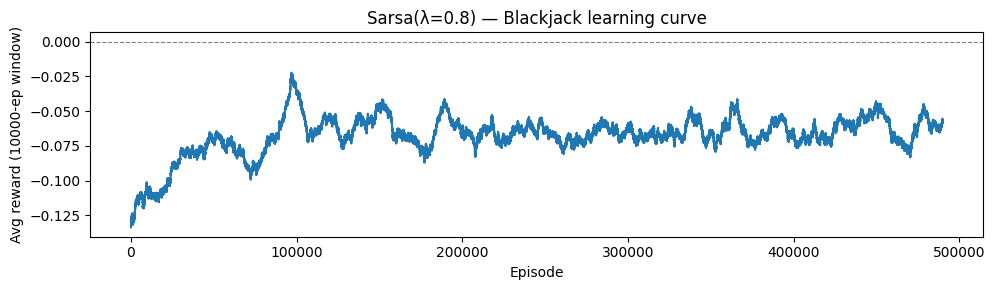

In [12]:

Q_sarsa_lam, rewards_sarsa_lam = sarsa_lambda_control(
    n_episodes=500_000, alpha=0.01, gamma=1.0, lam=0.8
)

policy_sarsa_lam = np.argmax(Q_sarsa_lam, axis=-1)
print("Sarsa(λ) training complete.")
print(f"States visited at least once: {int((Q_sarsa_lam.any(axis=-1)).sum())} / {10*10*2}")

# Learning curve
window = 10_000
avg_rewards_lam = np.convolve(rewards_sarsa_lam, np.ones(window) / window, mode="valid")
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(avg_rewards_lam)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Avg reward ({window}-ep window)")
ax.set_title("Sarsa(λ=0.8) — Blackjack learning curve")
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


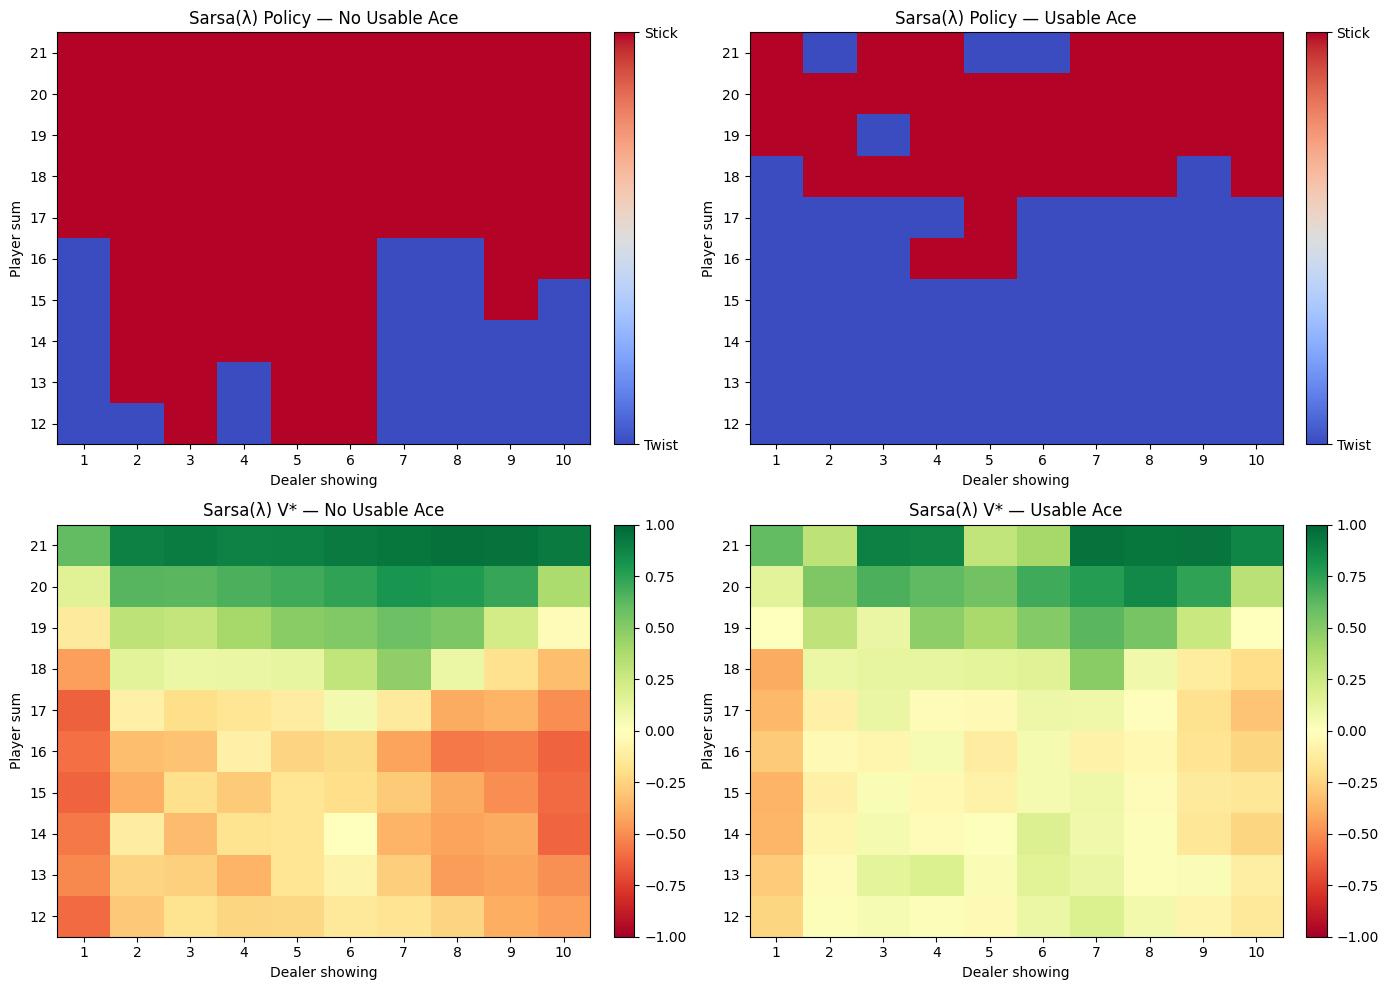

In [13]:

# ── Visualise Sarsa(λ) policy & value function ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "Sarsa(λ) Policy — No Usable Ace",
    "Sarsa(λ) Policy — Usable Ace",
    "Sarsa(λ) V* — No Usable Ace",
    "Sarsa(λ) V* — Usable Ace",
]

for col, u_ace in enumerate([0, 1]):
    # ── Policy heatmap ──
    ax = axes[0, col]
    im = ax.imshow(
        policy_sarsa_lam[:, :, u_ace],
        cmap="coolwarm",
        origin="lower",
        aspect="auto",
        vmin=0, vmax=1,
    )
    ax.set_title(titles[col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

    # ── Value function heatmap ──
    V_lam = np.max(Q_sarsa_lam[:, :, u_ace, :], axis=-1)
    ax = axes[1, col]
    im = ax.imshow(
        V_lam,
        cmap="RdYlGn",
        origin="lower",
        aspect="auto",
        vmin=-1, vmax=1,
    )
    ax.set_title(titles[2 + col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


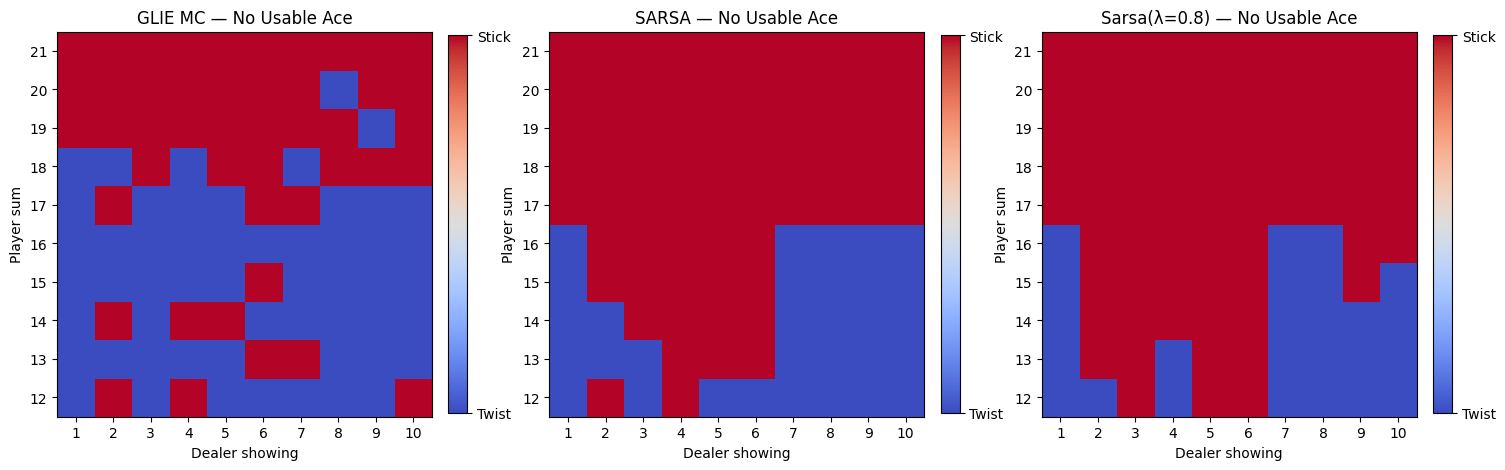

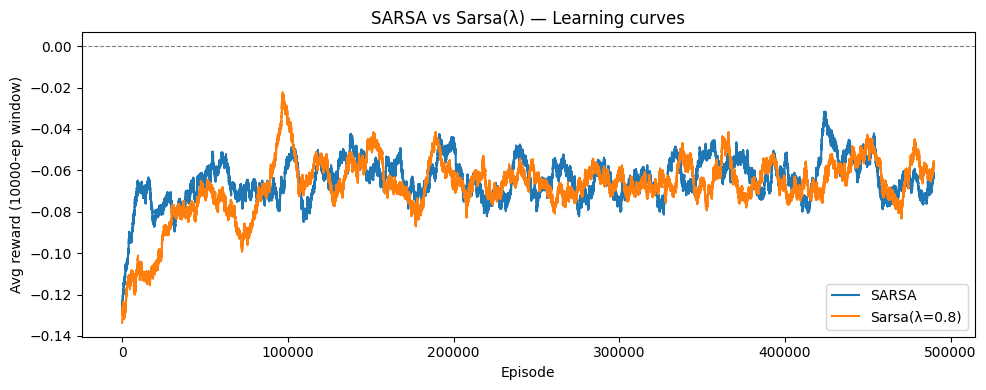

In [14]:

# ── Compare MC vs SARSA vs Sarsa(λ) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, (label, pol) in enumerate(
    [("GLIE MC", policy), ("SARSA", policy_sarsa), ("Sarsa(λ=0.8)", policy_sarsa_lam)]
):
    ax = axes[col]
    im = ax.imshow(
        pol[:, :, 0], cmap="coolwarm", origin="lower", aspect="auto", vmin=0, vmax=1
    )
    ax.set_title(f"{label} — No Usable Ace")
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

# Learning curves comparison
fig2, ax2 = plt.subplots(figsize=(10, 4))
window = 10_000
for label, rewards in [("SARSA", rewards_sarsa), ("Sarsa(λ=0.8)", rewards_sarsa_lam)]:
    avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax2.plot(avg, label=label)
ax2.set_xlabel("Episode")
ax2.set_ylabel(f"Avg reward ({window}-ep window)")
ax2.set_title("SARSA vs Sarsa(λ) — Learning curves")
ax2.axhline(0, color="grey", ls="--", lw=0.8)
ax2.legend()
plt.tight_layout()
plt.show()


## Off-Policy learning


**Core idea:** Evaluate target policy $π(a|s)$ to compute $v_π(s)$ or $q_π(s,a)$,
while generating experience by following a **different behaviour policy μ(a|s)**.

$$\{S_1, A_1, R_2, ..., S_T\} \sim \mu$$


> The trajectory is sampled from behavior policy μ, but we learn about π.


---

### Why does this matter?

- **Learn from observing humans or other agents**
  — you watch someone else act and extract value estimates without controlling the environment yourself.

- **Re-use experience from old policies π₁, π₂, ..., π_{t-1}**
  — replay past trajectories instead of discarding them; improves data efficiency.

- **Learn the *optimal* policy while following an *exploratory* behaviour policy**
  — e.g. Q-learning: behaviour policy explores (ε-greedy), target policy is greedy.
  Separates *exploration* from *what you're trying to learn*.

- **Learn about *multiple* policies while following *one* policy**
  — a single stream of experience can simultaneously update estimates for several target policies.


### Importance Sampling

**Goal:** Estimate $E_{X \sim P}[f(X)]$ but we can **only draw samples from Q, not P**.

$$
\mathbb{E}_{X \sim P}[f(X)]
= \sum P(X)\,f(X)
= \sum Q(X)\,\frac{P(X)}{Q(X)}\,f(X)
= \mathbb{E}_{X \sim Q}\!\left[\frac{P(X)}{Q(X)}\,f(X)\right]
$$

Writing $\mathbb{E}_{X \sim Q}$ is just shorthand for "multiply each term by Q(X) and sum".

---

### Step-by-step

1. **Start:** expectation under P — we want this, but can't sample from P directly.

2. **Multiply and divide by Q(X):** algebraically equivalent, Q(X) ≠ 0 wherever P(X) > 0.

3. **Rewrite as expectation under Q:** now we *can* sample X ~ Q and reweight each sample by the ratio P(X)/Q(X).

---

### The importance weight

$$w(X) = \frac{P(X)}{Q(X)}$$

- **w > 1** — X is more likely under P than Q → upweight this sample.
- **w < 1** — X is more likely under Q than P → downweight it.
- **w = 1** — P = Q, no correction needed (on-policy case).

---

### Connection to off-policy RL

| Symbol | RL meaning |
|--------|-----------|
| P      | target policy π |
| Q      | behaviour policy μ |
| f(X)   | return G_t (or TD target) |

Samples come from μ, but the importance ratio π/μ corrects them so updates apply to π.

> **Caveat:** if P and Q differ a lot, weights can have very high variance.
> Truncation (e.g. PPO clip) or weighted IS are common fixes.

NB: used in other ML areas like probabilistic inference, generative models (VAE), rare event estimation,...


### Importance Sampling (IS) for Off-Policy Monte-Carlo

**Core idea:** use trajectories generated by behaviour policy μ to evaluate target policy π,
by reweighting returns with the ratio of action probabilities.

---

### Corrected Return

Multiply IS corrections **at every step** from t to T:

$$
G_t^{\pi/\mu} = \frac{\pi(A_t|S_t)}{\mu(A_t|S_t)} \frac{\pi(A_{t+1}|S_{t+1})}{\mu(A_{t+1}|S_{t+1})} \cdots \frac{\pi(A_T|S_T)}{\mu(A_T|S_T)}\, G_t
$$

Each ratio $\frac{\pi(A_k|S_k)}{\mu(A_k|S_k)}$ asks:
> "How much more/less likely would π have taken this action compared to μ?"

The product chains these corrections across the **whole episode** — because the full return
$G_t$ depends on every action taken until T, each one needs to be corrected.

---

### Value Update

$$
V(S_t) \leftarrow V(S_t) + \alpha \Big( G_t^{\pi/\mu} - V(S_t) \Big)
$$

Standard MC update, but using the **corrected** return $G_t^{\pi/\mu}$ instead of the raw $G_t$.

---

### Caveats

- **Coverage requirement:** μ(a|s) = 0 whenever π(a|s) > 0 is forbidden —
  if μ never takes an action that π would, we can't correct for it (division by zero).
  Formally: π must be *absolutely continuous* with respect to μ.

- **Variance explosion:** the product of T ratios can be extremely large or small,
  especially over long episodes. This is the main practical weakness of MC IS.
  Common fixes: weighted IS, per-decision IS, or clipping (e.g. PPO).

### Importance Sampling for Off-Policy TD

**Core idea:** same as MC, but TD only bootstraps **one step** ahead —
so only **one IS correction** is needed instead of a product over the whole episode.

---

### Update Rule

$$
V(S_t) \leftarrow V(S_t) + \alpha \left( \frac{\pi(A_t|S_t)}{\mu(A_t|S_t)} \big(R_{t+1} + \gamma V(S_{t+1})\big) - V(S_t) \right)
$$

- $R_{t+1} + \gamma V(S_{t+1})$ — standard TD target, bootstrapped from next state

- $\frac{\pi(A_t|S_t)}{\mu(A_t|S_t)}$ — single IS weight correcting for the one action taken at time t

- $\frac{\pi(A_t|S_t)}{\mu(A_t|S_t)}$ is a ratio of probabilities of taking same action
    - μ took action a with probability 0.1, but π would have taken it with 0.4 → ratio = 4 → upweight this sample
    - μ took action a with probability 0.8, but π would have taken it with 0.2 → ratio = 0.25 →downweight this sample

---

### Why only one ratio?

TD looks only **one step ahead**, so only the action $A_t$ at the current step
was chosen by μ instead of π. There are no future actions in the target to correct for.

Compare to MC where the full return $G_t$ depends on every future action → product of T-t ratios.

---

### Key advantage over MC importance sampling

| | MC IS | TD IS |
|---|---|---|
| IS corrections per update | T − t (whole episode) | 1 (single step) |
| Variance | Very high | Much lower |
| Policy similarity required | Over entire episode | Only at current step |


Policies only need to be similar **locally** (at the current state-action over a single step), not globally across the whole trajectory.

### Q-Learning

Off-policy learning of action-values Q(s, a) — **no importance sampling required**.

---

### How it works

- **Behaviour policy** μ generates the actual trajectory: $A_{t+1} \sim \mu(\cdot|S_t)$
  — this is what the agent actually does (e.g. ε-greedy, random exploration)

- **Target policy** π selects the **alternative action**: $A' \sim \pi(\cdot|S_t)$
  — this is what we're learning about (e.g. greedy)

- Update $Q(S_t, A_t)$ towards the value of the **alternative** action A', not the one actually taken

---

### Update Rule

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big( \underbrace{R_{t+1} + \gamma Q(S_{t+1}, A')}_{\text{TD target under } \pi} - Q(S_t, A_t) \Big)
$$

- $R_{t+1}$ — reward from action actually taken by μ
- $Q(S_{t+1}, A')$ — value of the action π *would* choose next
- The TD error pushes $Q(S_t, A_t)$ toward what π thinks is best

---

### Why no importance sampling?

IS was needed when we used the **return** $G_t$ (MC) or **TD target** directly from μ's actions.
Here we **explicitly substitute** π's action $A'$ into the TD target — so the target already
reflects π, no reweighting needed.

In the standard case where π is **greedy**:

$$A' = \argmax_{a} Q(S_{t+1}, a)$$

This gives the classic Q-learning update:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big( R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \Big)
$$

> The agent explores freely with μ, but always learns as if it acted greedily.
> This is the key elegance of Q-learning.

### Off-Policy Control with Q-Learning

We now allow both behaviour and target policies to improve

Both policies improve simultaneously — this is what makes Q-learning a **control** algorithm,
not just a prediction one.

---

### The two policies

| Policy | Role | Strategy |
|--------|------|----------|
| π (target) | what we're learning | greedy w.r.t. Q(s,a) |
| μ (behaviour) | what generates experience | ε-greedy w.r.t. Q(s,a) |

- **π is greedy:** always picks the best known action
$$\pi(S_{t+1}) = \argmax_{a'} Q(S_{t+1}, a')$$

- **μ is ε-greedy:** mostly greedy, but explores randomly with probability ε
  — ensures coverage (visits all state-action pairs)

---

### TD Target Simplification

Starting from the general off-policy TD target:

$$R_{t+1} + \gamma Q(S_{t+1}, A')$$

Substitute π's greedy choice for $A'$:

$$= R_{t+1} + \gamma Q(S_{t+1}, \argmax_{a'} Q(S_{t+1}, a'))$$

Since $Q(s, \argmax_a Q(s,a)) = \max_a Q(s,a)$:

$$= R_{t+1} + \max_{a'} \gamma Q(S_{t+1}, a')$$

---

### Final Q-Learning Update

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\Big(R_{t+1} + \max_{a'} \gamma Q(S_{t+1}, a') - Q(S_t, A_t)\Big)
$$

> The $\max$ operator is the direct consequence of π being greedy.
> No importance sampling needed — π's action is substituted analytically, not sampled.

---

### Why does this work?

Both policies improve together:
- Q improves → π (greedy over Q) improves → better target
- μ (ε-greedy over Q) also improves → bet


<img src="./imgs/image-99.png" width="500px"/>



## Q-Learning Algorithm

- Initialize Q(s, a) arbitrarily for all s ∈ S, a ∈ A(s), and Q(terminal-state, ·) = 0 (action-value of being in a terminal state is always 0 (no future rewards possible), which is a boundary condition to make the Bellman equation consistent)

- **Repeat** for each episode:

  - Initialize S to starting state given by env (not 0)

  - **Repeat** for each step of episode:

    - Choose A from S using policy derived from Q (e.g., ε-greedy)

    - Take action A, observe R, S'

    - Update:
      $$Q(S, A) \leftarrow Q(S, A) + \alpha\Big[R + \gamma \max_a Q(S', a) - Q(S, A)\Big]$$

    - S ← S'

  - Until S is terminal

### Q-Learning — Blackjack

In [16]:

# ── Q-Learning (Off-Policy TD Control) — Blackjack ──────────────────
def q_learning(n_episodes=500_000, alpha=0.01, gamma=1.0, epsilon_start=1.0):
    """
    Off-policy Q-learning with ε-greedy behaviour policy on Blackjack.
    Target policy is greedy (max_a Q), behaviour policy is ε-greedy.
    ε decays as 1/k (GLIE schedule), floored at 0.01.
    """
    Q = np.zeros((10, 10, 2, len(ACTIONS)))
    env = BlackjackEnv()
    episode_rewards = []

    for k in range(1, n_episodes + 1):
        epsilon = max(epsilon_start / k, 0.01)

        state = env.reset()
        total_reward = 0.0

        done = False
        while not done:
            # Behaviour policy: ε-greedy
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done = env.step(ACTIONS[action])
            total_reward += reward

            sa = (*state_to_idx(state), action)
            if done:
                # Terminal: max_a Q(S', a) = 0
                Q[sa] += alpha * (reward - Q[sa])
            else:
                # Target policy: greedy → use max over next actions
                best_next = np.max(Q[state_to_idx(next_state)])
                Q[sa] += alpha * (reward + gamma * best_next - Q[sa])
                state = next_state

        episode_rewards.append(total_reward)

    return Q, episode_rewards


Q-Learning training complete.
States visited at least once: 200 / 200


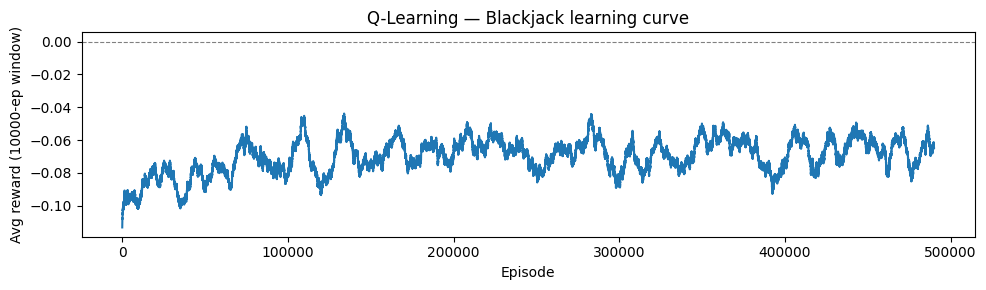

In [17]:

Q_ql, rewards_ql = q_learning(n_episodes=500_000, alpha=0.01, gamma=1.0)

policy_ql = np.argmax(Q_ql, axis=-1)
print("Q-Learning training complete.")
print(f"States visited at least once: {int((Q_ql.any(axis=-1)).sum())} / {10*10*2}")

# Learning curve
window = 10_000
avg_rewards_ql = np.convolve(rewards_ql, np.ones(window) / window, mode="valid")
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(avg_rewards_ql)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Avg reward ({window}-ep window)")
ax.set_title("Q-Learning — Blackjack learning curve")
ax.axhline(0, color="grey", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


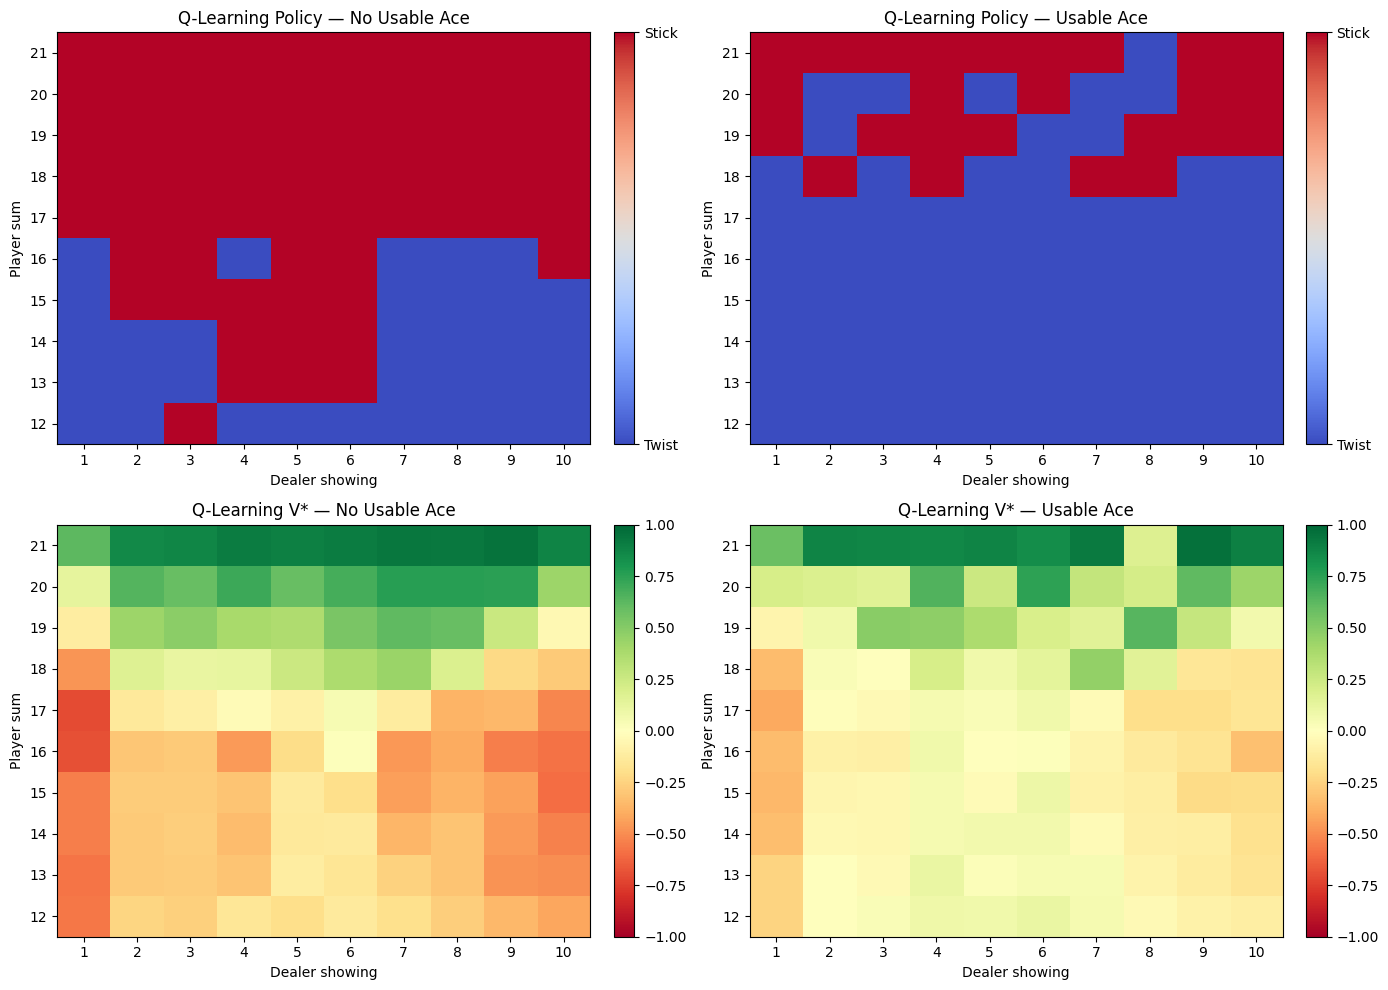

In [18]:

# ── Visualise Q-Learning policy & value function ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "Q-Learning Policy — No Usable Ace",
    "Q-Learning Policy — Usable Ace",
    "Q-Learning V* — No Usable Ace",
    "Q-Learning V* — Usable Ace",
]

for col, u_ace in enumerate([0, 1]):
    # ── Policy heatmap ──
    ax = axes[0, col]
    im = ax.imshow(
        policy_ql[:, :, u_ace],
        cmap="coolwarm",
        origin="lower",
        aspect="auto",
        vmin=0, vmax=1,
    )
    ax.set_title(titles[col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

    # ── Value function heatmap ──
    V_ql = np.max(Q_ql[:, :, u_ace, :], axis=-1)
    ax = axes[1, col]
    im = ax.imshow(
        V_ql,
        cmap="RdYlGn",
        origin="lower",
        aspect="auto",
        vmin=-1, vmax=1,
    )
    ax.set_title(titles[2 + col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


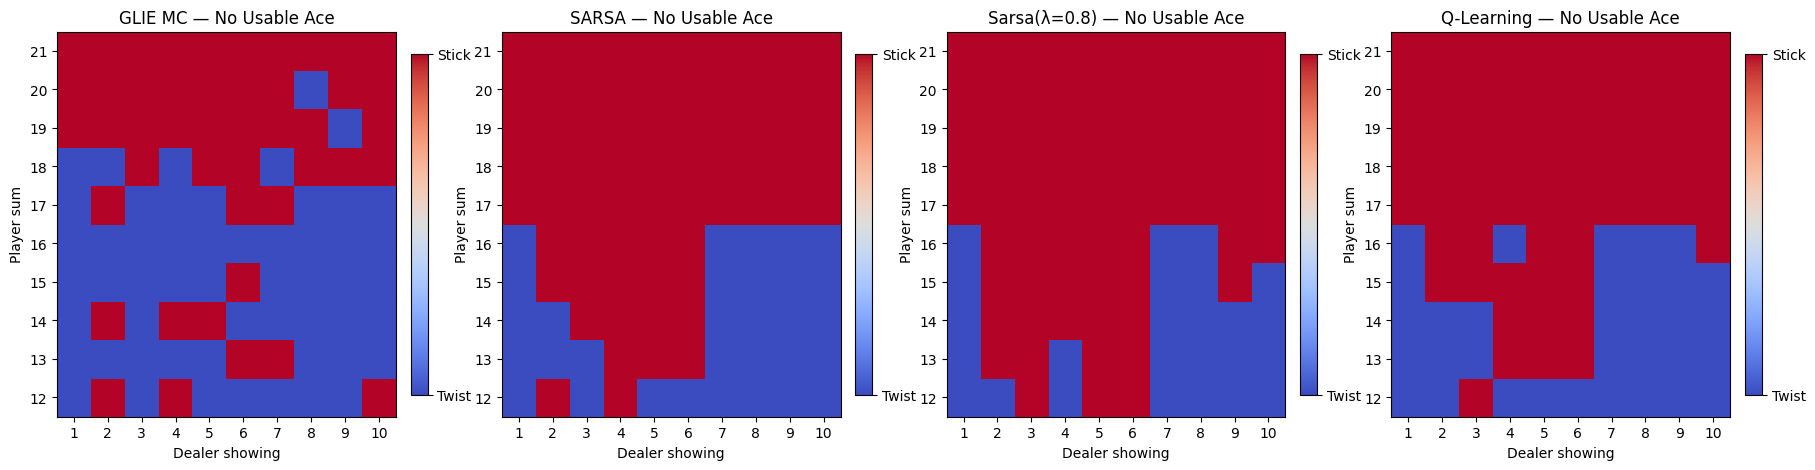

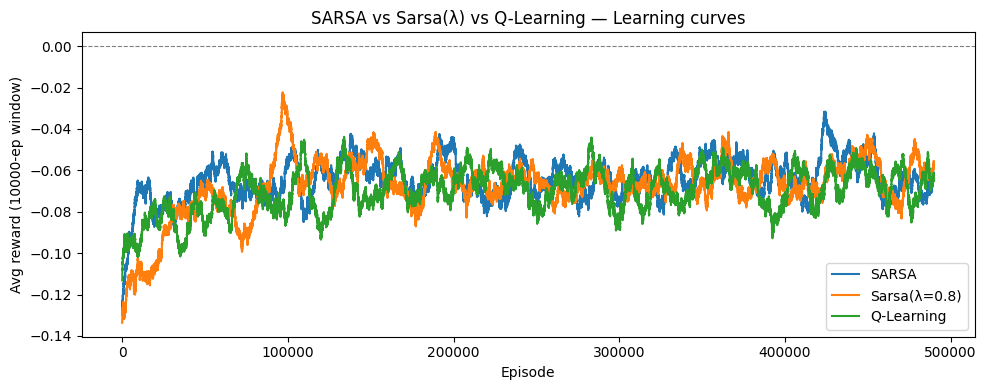

In [19]:

# ── Compare MC vs SARSA vs Sarsa(λ) vs Q-Learning ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

methods = [
    ("GLIE MC", policy),
    ("SARSA", policy_sarsa),
    ("Sarsa(λ=0.8)", policy_sarsa_lam),
    ("Q-Learning", policy_ql),
]

for col, (label, pol) in enumerate(methods):
    ax = axes[col]
    im = ax.imshow(
        pol[:, :, 0], cmap="coolwarm", origin="lower", aspect="auto", vmin=0, vmax=1
    )
    ax.set_title(f"{label} — No Usable Ace")
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

# Learning curves comparison
fig2, ax2 = plt.subplots(figsize=(10, 4))
window = 10_000
for label, rewards in [
    ("SARSA", rewards_sarsa),
    ("Sarsa(λ=0.8)", rewards_sarsa_lam),
    ("Q-Learning", rewards_ql),
]:
    avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax2.plot(avg, label=label)
ax2.set_xlabel("Episode")
ax2.set_ylabel(f"Avg reward ({window}-ep window)")
ax2.set_title("SARSA vs Sarsa(λ) vs Q-Learning — Learning curves")
ax2.axhline(0, color="grey", ls="--", lw=0.8)
ax2.legend()
plt.tight_layout()
plt.show()


## Relationship Between DP and TD

<img src="./imgs/image-100.png" width="600px" />



| Full Backup (DP) | Sample Backup (TD) |
|---|---|
| **Iterative Policy Evaluation** | **TD Learning** |
| V(s) ← E[R + γV(S') \| s] | V(S) ←α R + γV(S') |
| **Q-Policy Iteration** | **Sarsa** |
| Q(s,a) ← E[R + γQ(S',A') \| s,a] | Q(S,A) ←α R + γQ(S',A') |
| **Q-Value Iteration** | **Q-Learning** |
| Q(s,a) ← E[R + γ max_{a'∈A} Q(S',a') \| s,a] | Q(S,A) ←α R + γ max_{a'∈A} Q(S',a') |

where x ←α y ≡ x ← x + α(y − x)

### Explanation

The table maps each **DP (Dynamic Programming)** algorithm to its **TD (Temporal Difference)** counterpart.

**Key structural difference:**
- **DP (Full Backup):** updates use the *expected value* over all possible next states — requires a model (transition probabilities).
- **TD (Sample Backup):** updates use a *single sampled* transition — model-free, learns from experience.

**The `←α` operator** is just a weighted update (exponential moving average):
```
x ← x + α(y − x)
```
It moves x toward target y by step size α, rather than replacing x outright.

---

### Row by row

| DP | TD | What's learned | Policy |
|---|---|---|---|
| Iterative Policy Evaluation | TD(0) | V(s) — state value | fixed π |
| Q-Policy Iteration | Sarsa | Q(s,a) — action value | on-policy (follows π) |
| Q-Value Iteration | Q-Learning | Q(s,a) — action value | off-policy (greedy target) |

- **Sarsa** is **on-policy**: the next action A' is sampled from the *current* policy → learns Q_π
- **Q-Learning** is **off-policy**: bootstraps with `max_a' Q(S',a')` regardless of what action is actually taken → learns Q* directly